In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams.update({
    'figure.figsize': (18, 4.5),
    'font.size': 12,
})

In [2]:


def vector_field(t, state):
    x, y = state
    dx = -(1 - t) * x - 2 * t * y
    dy = 2 * t * x - (1 - t) * y
    return [dx, dy]

def vector_field_grid(t, X, Y):
    U = -(1 - t) * X - 2 * t * Y
    V = 2 * t * X - (1 - t) * Y
    return U, V

In [3]:

n_grid = 16
grid_range = 3.0
xs = np.linspace(-grid_range, grid_range, n_grid)
ys = np.linspace(-grid_range, grid_range, n_grid)
X, Y = np.meshgrid(xs, ys)

In [4]:
# solve ODE trajectories
t_span = (0, 1.0)
t_eval = np.linspace(0, 1.0, 1000)

initial_conditions = [
    [2.5, 1.0],
    [-2.0, 2.0],
    [1.0, -2.5],
    [-1.5, -1.5],
    [2.8, -0.5],
]

trajectories = []
for x0 in initial_conditions:
    sol = solve_ivp(vector_field, t_span, x0, t_eval=t_eval, method='RK45')
    trajectories.append(sol)

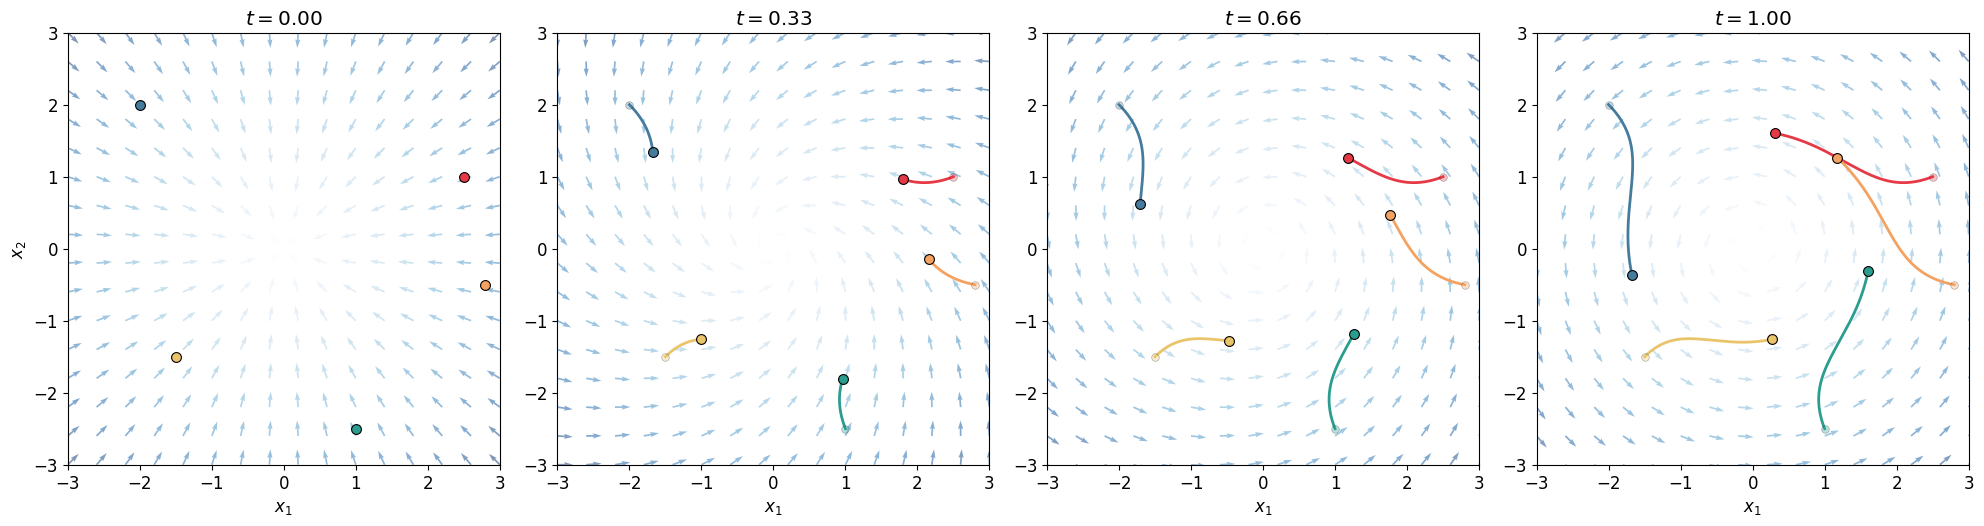

In [5]:

times_to_show = [0.0, 0.33, 0.66, 1.0]
colours = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a', '#f4a261']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, t_val in zip(axes, times_to_show):

    U, V = vector_field_grid(t_val, X, Y)
    speed = np.sqrt(U**2 + V**2)
    U_norm = U / (speed + 1e-8)
    V_norm = V / (speed + 1e-8)
    
    ax.quiver(X, Y, U_norm, V_norm, speed, cmap='Blues', alpha=0.5, scale=28, width=0.004)
    

    t_idx = np.argmin(np.abs(t_eval - t_val))
    

    for sol, c in zip(trajectories, colours):
        ax.plot(sol.y[0, :t_idx+1], sol.y[1, :t_idx+1], c=c, linewidth=2, zorder=5)

        ax.scatter(sol.y[0, t_idx], sol.y[1, t_idx], c=c, s=50, zorder=6, 
                   edgecolors='black', linewidth=0.8)

        if t_val > 0:
            ax.scatter(sol.y[0, 0], sol.y[1, 0], c=c, s=30, zorder=5, alpha=0.3,
                       edgecolors='black', linewidth=0.5)
    
    ax.set_title(f'$t = {t_val:.2f}$')
    ax.set_xlim(-grid_range, grid_range)
    ax.set_ylim(-grid_range, grid_range)
    ax.set_aspect('equal')
    ax.set_xlabel('$x_1$')
    if t_val == 0:
        ax.set_ylabel('$x_2$')

plt.tight_layout()
plt.savefig('vector_field_time_dependent.pdf', bbox_inches='tight')
plt.show()